In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import pylab as pl
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score
from sklearn import feature_selection
from sklearn.cluster import KMeans 

In [3]:
df_original = pd.read_csv("C:\\Users\\Massiel\\Desktop\\Datasets\\Life Expectancy Data.csv")
#df = pd.read_csv("C:\\Users\\Massiel\\Desktop\\Datasets\\Life-Expectancy-Data-Updated.csv")
df_original.head(10)

,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5
5,Afghanistan,2010,Developing,58.8,279.0,74,0.01,79.679367,66.0,1989,...,66.0,9.20,66.0,0.1,553.328940,2883167.0,18.4,18.4,0.448,9.2
6,Afghanistan,2009,Developing,58.6,281.0,77,0.01,56.762217,63.0,2861,...,63.0,9.42,63.0,0.1,445.893298,284331.0,18.6,18.7,0.434,8.9
7,Afghanistan,2008,Developing,58.1,287.0,80,0.03,25.873925,64.0,1599,...,64.0,8.33,64.0,0.1,373.361116,2729431.0,18.8,18.9,0.433,8.7
8,Afghanistan,2007,Developing,57.5,295.0,82,0.02,10.910156,63.0,1141,...,63.0,6.73,63.0,0.1,369.835796,26616792.0,19.0,19.1,0.415,8.4
9,Afghanistan,2006,Developing,57.3,295.0,84,0.03,17.171518,64.0,1990,...,58.0,7.43,58.0,0.1,272.563770,2589345.0,19.2,19.3,0.405,8.1


In [4]:
# Remove spaces from column names
df_original.columns = ['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population',
       'thinness 10-19 years', 'thinness 5-9 years',
       'Income composition of resources', 'Schooling']

In [5]:
# 'Year' will not be a relevent feature
df_original = df_original.drop('Year', axis=1)

In [6]:
df_original.shape

(2938, 21)

In [7]:
df_original.dtypes

Country                             object
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness 10-19 years               float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object

In [8]:
df_original.isnull().sum().sum()

2563

In [9]:
df_original.isnull().sum()

Country                              0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness 10-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [10]:
df = df_original.copy()
# Columns with missing values
numeric_columns = ['Life expectancy', 'Adult Mortality', 'Alcohol', 'Hepatitis B', 
                  'BMI', 'Polio', 'Total expenditure', 'Diphtheria', 'GDP',
                  'thinness 10-19 years', 'thinness 5-9 years', 
                  'Income composition of resources', 'Schooling', 'Population']

print("Missing values before replacement:")
print(df[numeric_columns].isnull().sum())

# Replace missing values with country averages
for col in numeric_columns:
    if col in df.columns and df[col].isnull().sum() > 0:
        #print(f"\nHandling missing values for: {col}")
        #print(f"Missing before: {df[col].isnull().sum()}")
        
        # Fill with country-specific median
        df[col] = df.groupby('Country')[col].transform(
            lambda x: x.fillna(x.median())
        )
        
        #print(f"Missing after country imputation: {df[col].isnull().sum()}")

# Check which columns still have missing values
remaining_missing = df[numeric_columns].isnull().sum()
print(f"\nRemaining missing values after country-based imputation:")
print(remaining_missing[remaining_missing > 0])

print(f"\nTotal remaining missing values: {df.isnull().sum().sum()}")
print(f"Dataset shape: {df.shape}")

Missing values before replacement:
Life expectancy                     10
Adult Mortality                     10
Alcohol                            194
Hepatitis B                        553
BMI                                 34
Polio                               19
Total expenditure                  226
Diphtheria                          19
GDP                                448
thinness 10-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
Population                         652
dtype: int64

Remaining missing values after country-based imputation:
Life expectancy                     10
Adult Mortality                     10
Alcohol                             17
Hepatitis B                        144
BMI                                 34
Total expenditure                   32
GDP                                405
thinness 10-19 years                34
thinness 5-9 years                  

In [11]:
# Remove population column - 22% missing
df = df.drop('Population', axis=1)
df.isnull().sum()

Country                              0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                             17
percentage expenditure               0
Hepatitis B                        144
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                                0
Total expenditure                   32
Diphtheria                           0
HIV/AIDS                             0
GDP                                405
thinness 10-19 years                34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64

In [12]:
df.isnull().sum().sum()

1050

In [13]:
df = df.dropna()
df.shape

(2352, 20)

In [14]:
df_original.shape

(2938, 21)

In [15]:
df.shape[0]/df_original.shape[0]
# About 20% of rows were dropped.

0.8005445881552076

In [16]:
df.isnull().sum()

Country                            0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
BMI                                0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
HIV/AIDS                           0
GDP                                0
thinness 10-19 years               0
thinness 5-9 years                 0
Income composition of resources    0
Schooling                          0
dtype: int64

# EXPLORATORY DATA ANALYSIS

In [18]:
df.describe()

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 10-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000,2352.000000
mean,68.882058,165.643282,32.580782,4.335880,692.937078,79.715986,2415.935799,37.768750,45.184949,81.990646,5.745153,81.982143,1.977381,6438.063904,5.049235,5.098214,0.619803,11.900765
std,9.468580,127.086757,129.978562,3.944907,1711.594247,24.743768,11355.939125,19.950977,176.691235,23.553665,2.303502,23.683856,5.575703,12580.852957,4.523103,4.612024,0.208853,3.241099
min,36.300000,1.000000,0.000000,0.010000,0.000000,2.000000,0.000000,1.400000,0.000000,3.000000,0.370000,2.000000,0.100000,1.681350,0.100000,0.100000,0.000000,0.000000
25%,62.975000,74.000000,0.000000,0.695000,22.166537,74.000000,0.000000,18.800000,1.000000,77.000000,4.200000,78.000000,0.100000,445.801223,1.700000,1.700000,0.487000,10.000000
50%,71.850000,143.000000,3.000000,3.565000,102.102976,91.000000,18.000000,42.600000,4.000000,92.000000,5.630000,92.000000,0.100000,1633.115790,3.500000,3.600000,0.674000,12.300000
75%,75.300000,227.250000,20.000000,7.202500,498.036563,96.000000,354.750000,55.800000,25.000000,97.000000,7.230000,97.000000,0.900000,5422.063855,7.225000,7.300000,0.770250,14.100000
max,89.000000,723.000000,1800.000000,17.870000,18961.348600,99.000000,212183.000000,77.600000,2500.000000,99.000000,14.390000,99.000000,50.600000,119172.741800,27.700000,28.600000,0.937000,20.700000


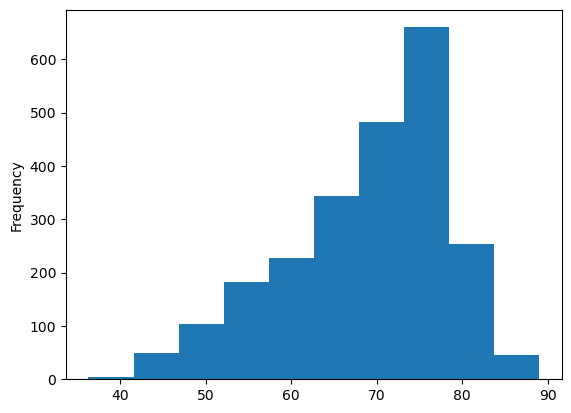

In [19]:
df["Life expectancy"].plot(kind="hist")
plt.show()
# 'Life expectancy' is left-skewed.

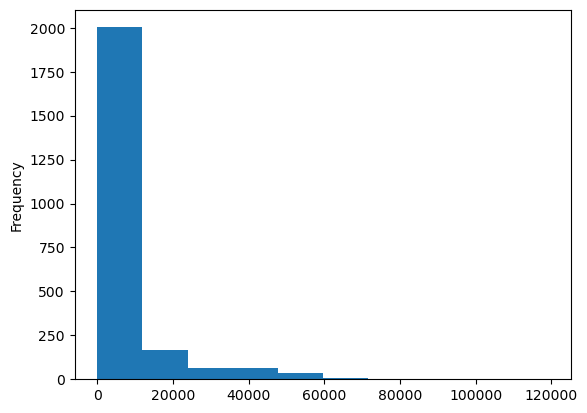

In [20]:
df["GDP"].plot(kind="hist")
plt.show()
# 'GDP' is very heavily right-skewed.

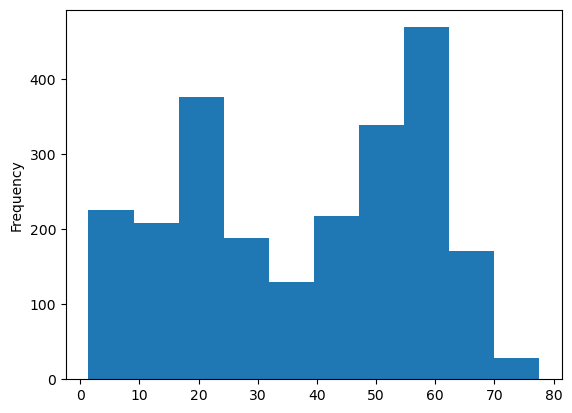

In [21]:
df["BMI"].plot(kind="hist")
plt.show()
# 'BMI' has a bimodal distribution. This is possibly reflective of country 'Status'.

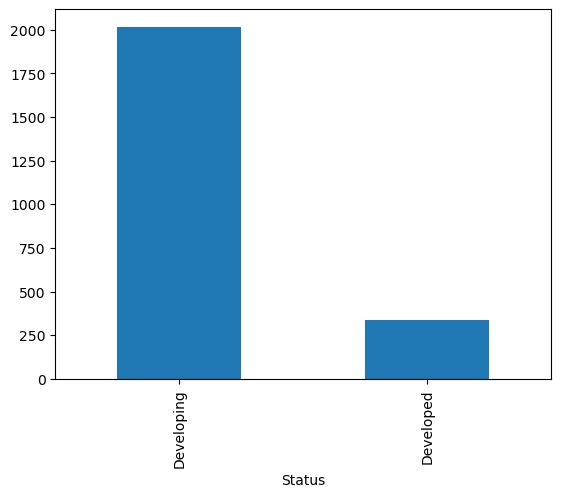

In [22]:
df["Status"].value_counts().plot(kind='bar')
plt.show()
# There is an imbalance of status types in the data. 'Developing' is much more represented.

In [23]:
df["Status"].value_counts()

Status
Developing    2016
Developed      336
Name: count, dtype: int64

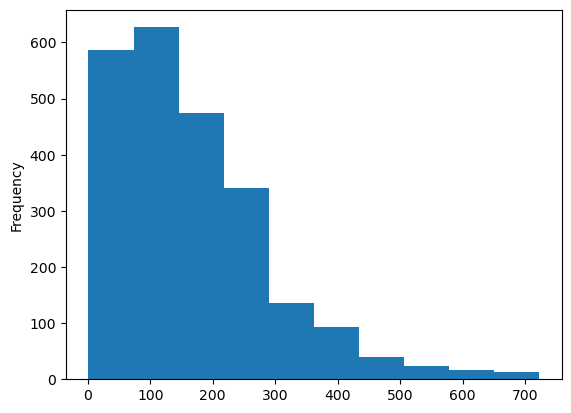

In [24]:
df['Adult Mortality'].plot(kind="hist")
plt.show()
# Probability of dying before 60 years old per 1000 population. Similar to life expectancy.

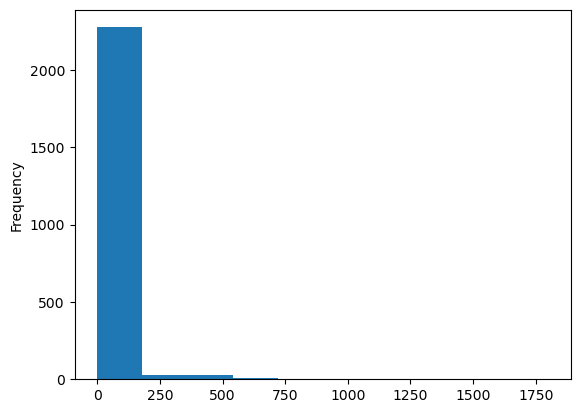

In [25]:
df["infant deaths"].plot(kind="hist")
plt.show()

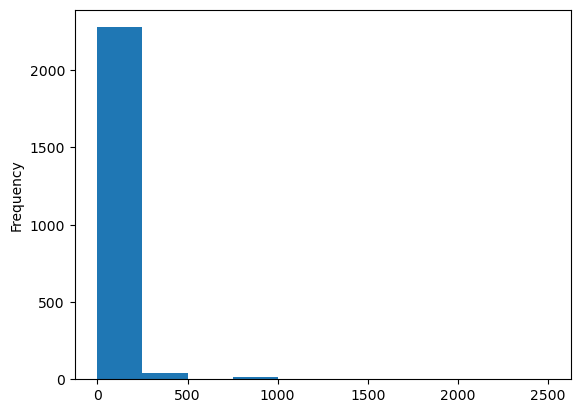

In [26]:
df["under-five deaths"].plot(kind="hist")
plt.show()

In [27]:
# Check for multicollinearity
df_nums = df.drop(['Country','Status'], axis=1)
correlation_matrix = df_nums.corr()
correlation_matrix

,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 10-19 years,thinness 5-9 years,Income composition of resources,Schooling
Life expectancy,1.000000,-0.675639,-0.175898,0.348563,0.398341,0.249716,-0.146404,0.580864,-0.201949,0.445080,0.147144,0.458995,-0.575376,0.443270,-0.455639,-0.450613,0.712836,0.734556
Adult Mortality,-0.675639,1.000000,0.057275,-0.143052,-0.238974,-0.128636,0.008338,-0.377964,0.071903,-0.240007,-0.047035,-0.234014,0.537131,-0.276662,0.274257,0.282583,-0.434526,-0.419919
infant deaths,-0.175898,0.057275,1.000000,-0.092297,-0.089136,-0.225731,0.522739,-0.225783,0.996621,-0.163132,-0.123407,-0.164555,0.012383,-0.104105,0.481220,0.488059,-0.142817,-0.198437
Alcohol,0.348563,-0.143052,-0.092297,1.000000,0.370374,0.054647,-0.024982,0.317799,-0.087288,0.195194,0.286713,0.190831,-0.021635,0.330268,-0.399034,-0.385843,0.424081,0.530085
percentage expenditure,0.398341,-0.238974,-0.089136,0.370374,1.000000,0.008675,-0.068417,0.255761,-0.091684,0.161963,0.173207,0.157958,-0.106965,0.886249,-0.258296,-0.259364,0.383221,0.391971
Hepatitis B,0.249716,-0.128636,-0.225731,0.054647,0.008675,1.000000,-0.132026,0.164151,-0.234645,0.465680,0.070952,0.571395,-0.113259,0.064642,-0.118833,-0.123390,0.187219,0.229516
Measles,-0.146404,0.008338,0.522739,-0.024982,-0.068417,-0.132026,1.000000,-0.167157,0.530091,-0.120087,-0.091224,-0.122808,0.027163,-0.079814,0.234607,0.230853,-0.136933,-0.146660
BMI,0.580864,-0.377964,-0.225783,0.317799,0.255761,0.164151,-0.167157,1.000000,-0.235778,0.274315,0.174943,0.271351,-0.240692,0.300834,-0.525356,-0.534875,0.525037,0.570747
under-five deaths,-0.201949,0.071903,0.996621,-0.087288,-0.091684,-0.234645,0.530091,-0.235778,1.000000,-0.180895,-0.123216,-0.185133,0.024357,-0.107688,0.482638,0.488313,-0.161617,-0.214630
Polio,0.445080,-0.240007,-0.163132,0.195194,0.161963,0.465680,-0.120087,0.274315,-0.180895,1.000000,0.117655,0.664697,-0.153306,0.207900,-0.202337,-0.205984,0.372269,0.405502


In [28]:
# 'infant deaths' is included in 'under-five deaths'.
# This can lead to multicollinearity
df = df.drop('infant deaths', axis=1)

In [29]:
# High correlation with 'thinness 10-19 years'.
df = df.drop('thinness 5-9 years', axis=1)

In [30]:
# High correlation with 'GDP'.
df = df.drop('percentage expenditure', axis=1)

In [31]:
# Check for correlation after dropping features
df_nums = df.drop(['Country','Status'], axis=1)
correlation_matrix = df_nums.corr()
correlation_matrix

,Life expectancy,Adult Mortality,Alcohol,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 10-19 years,Income composition of resources,Schooling
Life expectancy,1.000000,-0.675639,0.348563,0.249716,-0.146404,0.580864,-0.201949,0.445080,0.147144,0.458995,-0.575376,0.443270,-0.455639,0.712836,0.734556
Adult Mortality,-0.675639,1.000000,-0.143052,-0.128636,0.008338,-0.377964,0.071903,-0.240007,-0.047035,-0.234014,0.537131,-0.276662,0.274257,-0.434526,-0.419919
Alcohol,0.348563,-0.143052,1.000000,0.054647,-0.024982,0.317799,-0.087288,0.195194,0.286713,0.190831,-0.021635,0.330268,-0.399034,0.424081,0.530085
Hepatitis B,0.249716,-0.128636,0.054647,1.000000,-0.132026,0.164151,-0.234645,0.465680,0.070952,0.571395,-0.113259,0.064642,-0.118833,0.187219,0.229516
Measles,-0.146404,0.008338,-0.024982,-0.132026,1.000000,-0.167157,0.530091,-0.120087,-0.091224,-0.122808,0.027163,-0.079814,0.234607,-0.136933,-0.146660
BMI,0.580864,-0.377964,0.317799,0.164151,-0.167157,1.000000,-0.235778,0.274315,0.174943,0.271351,-0.240692,0.300834,-0.525356,0.525037,0.570747
under-five deaths,-0.201949,0.071903,-0.087288,-0.234645,0.530091,-0.235778,1.000000,-0.180895,-0.123216,-0.185133,0.024357,-0.107688,0.482638,-0.161617,-0.214630
Polio,0.445080,-0.240007,0.195194,0.465680,-0.120087,0.274315,-0.180895,1.000000,0.117655,0.664697,-0.153306,0.207900,-0.202337,0.372269,0.405502
Total expenditure,0.147144,-0.047035,0.286713,0.070952,-0.091224,0.174943,-0.123216,0.117655,1.000000,0.126149,0.045406,0.090151,-0.235653,0.126008,0.222992
Diphtheria,0.458995,-0.234014,0.190831,0.571395,-0.122808,0.271351,-0.185133,0.664697,0.126149,1.000000,-0.160941,0.198659,-0.212914,0.398424,0.415524


# LINEAR REGRESSION

In [33]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [34]:
# Target = Life expectancy
# Test data is scaled so no feature is weighted more heavily than another.

In [35]:
# Only numerical features are used.
# 'Adult Mortality' was excluded because it overlaps with 'Life expectancy'.
df_lr = df
target = df['Life expectancy']
df_lr = df_lr.drop(['Life expectancy','Country','Status', 'Adult Mortality'], axis=1)
y = np.array(target).reshape(-1, 1).flatten()
X = np.array(df_lr)
X = scaler.fit_transform(X)

In [36]:
X.shape

(2352, 13)

In [37]:
y

array([65. , 59.9, 59.9, ..., 44.8, 45.3, 46. ])

In [38]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=33)
linreg = LinearRegression()
linreg.fit(X_train,y_train)

LinearRegression()

In [39]:
p_test = linreg.predict(X_test) # p_test is the array of predicted values
for i in range(10):
    print("%2d \t %2.2f \t %2.2f" % (i, p_test[i], y[i]))

 0 	 47.41 	 65.00
 1 	 75.49 	 59.90
 2 	 80.57 	 59.90
 3 	 80.36 	 59.50
 4 	 62.03 	 59.20
 5 	 70.26 	 58.80
 6 	 62.04 	 58.60
 7 	 72.33 	 58.10
 8 	 58.58 	 57.50
 9 	 77.32 	 57.30


In [40]:
w = linreg.coef_
wflat = w.flatten()
print(wflat)

[-2.75144729e-01 -2.25055885e-01 -7.48732985e-02  1.15657448e+00
  1.35525773e-03  7.59384440e-01  1.57993579e-01  1.00168713e+00
 -3.50474498e+00  8.94118415e-01 -4.05664359e-01  1.88515205e+00
  2.85855545e+00]


In [41]:
names = df_lr.columns.tolist()
len(names)

13

In [42]:
# Adding feature names to coefficients.
for i in range(len(names)):
    print("%7s   %2.2f" % (names[i], wflat[i]))

Alcohol   -0.28
Hepatitis B   -0.23
Measles   -0.07
    BMI   1.16
under-five deaths   0.00
  Polio   0.76
Total expenditure   0.16
Diphtheria   1.00
HIV/AIDS   -3.50
    GDP   0.89
thinness 10-19 years   -0.41
Income composition of resources   1.89
Schooling   2.86


In [43]:
# Visualize coefficients
%matplotlib inline
def plot_coefficients(model, n_features, feature_names):
    pl.barh(range(n_features), model.coef_, align='center')
    pl.yticks(np.arange(n_features), feature_names)
    pl.xlabel("Coefficient Value")
    pl.ylabel("Feature")
    pl.ylim(-1, n_features)
    pl.title('Feature Coefficients')

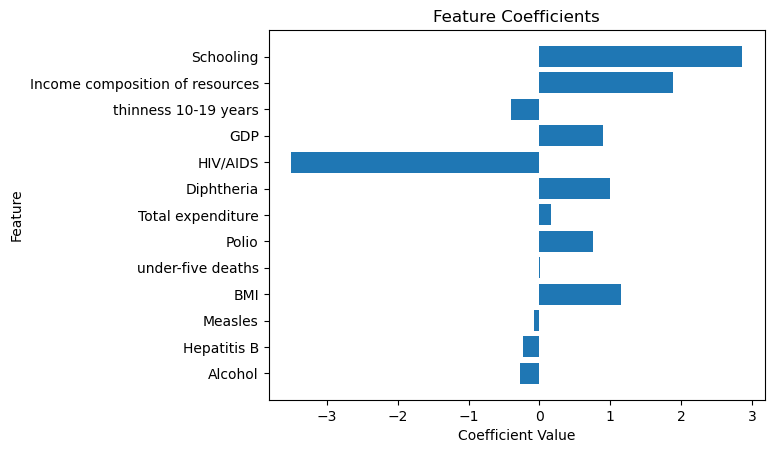

In [44]:
plot_coefficients(linreg, len(names), names)
plt.show()

In [45]:
# Errors on all training instances

p_train = linreg.predict(X_train) # p_train is the array of predicted values

# Array of errors
err_train = abs(p_train - y_train)

# Error values on the first 10 predictions
print(err_train[:10])

[2.61238142 1.1782735  3.68201349 2.82916761 1.47248403 3.22319289
 6.22408416 0.99780834 0.78511155 8.93416098]


In [46]:
# Sum of squared errors
sum_sq_err = np.dot(err_train,err_train)

# RMSE
rmse_train = np.sqrt(sum_sq_err/len(p_train))
print("RMSE on Training Data: ", rmse_train)

# Range for 'Life expectancy' is 36.3 - 89.0 years.

RMSE on Training Data:  4.456245301115573


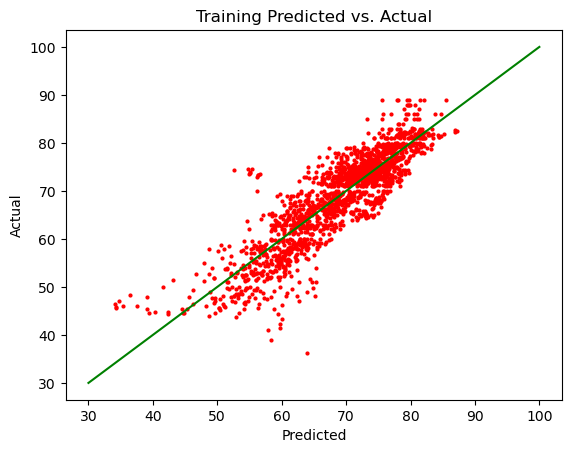

In [47]:
# Plot predicted against actual (in the training data)
%matplotlib inline
pl.plot(p_train, y_train,'ro', markersize=2)
pl.plot([30,100],[30,100], 'g-')
pl.xlabel('Predicted')
pl.ylabel('Actual')
pl.title('Training Predicted vs. Actual')
pl.show()

In [48]:
# RMSE on the test data
p_test = linreg.predict(X_test) # array of predicted values

# Array of errors
err_test = abs(p_test - y_test)

# Sum of squared errors
sum_sq_err = np.dot(err_test,err_test)

# RMSE
rmse_test = np.sqrt(sum_sq_err/len(p_test))
print("RMSE on Test Data: ", rmse_test)

RMSE on Test Data:  3.978546751699833


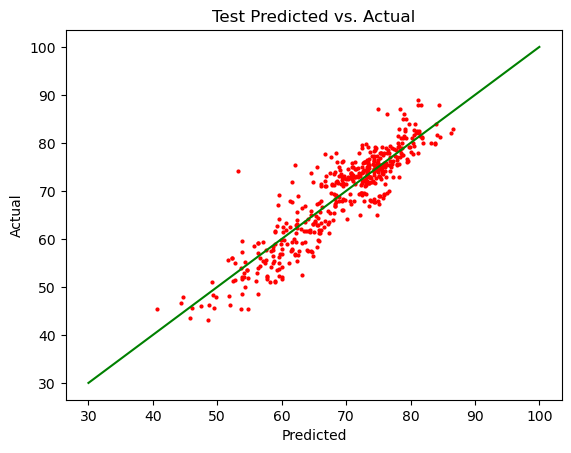

In [49]:
# Plot predicted against actual (in the test data)
%matplotlib inline
pl.plot(p_test, y_test,'ro', markersize=2)
pl.plot([30,100],[30,100], 'g-')
pl.xlabel('Predicted')
pl.ylabel('Actual')
pl.title('Test Predicted vs. Actual')
pl.show()

In [50]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse_test = np.sqrt(mean_squared_error(p_test, y_test))
print("RMSE on Test Data: ", rmse_test)

mae_test = mean_absolute_error(p_test, y_test)
print("MAE on Test Data: ", mae_test)

RMSE on Test Data:  3.978546751699833
MAE on Test Data:  3.080922652984593


In [51]:
def cross_validate(model, X, y, n, verbose=False):
    # model: regression model to be trained
    # X: the training data matrix
    # y: the training target variable array
    # n: the number of fold for x-validation
    # Returns mean RMSE across all folds
    
    from sklearn.metrics import mean_squared_error   
    from sklearn.model_selection import KFold
    
    kf = KFold(n_splits=n)

    xval_err = 0
    f = 1
    for train,test in kf.split(X):
        model.fit(X[train],y[train]) # fit model to the training partition in this fold
        p_test = model.predict(X[test]) # apply trained model to test partition in this fold
        rmse_test = np.sqrt(mean_squared_error(p_test, y[test]))
        if verbose:
            print("Fold %2d RMSE: %.4f" % (f, rmse_test))
        xval_err += rmse_test
        f += 1
    return xval_err/n

In [52]:
rmse_10cv = cross_validate(linreg, X_train, y_train, 10, verbose=True)

Fold  1 RMSE: 4.0685
Fold  2 RMSE: 5.1149
Fold  3 RMSE: 3.9588
Fold  4 RMSE: 4.0602
Fold  5 RMSE: 3.9073
Fold  6 RMSE: 4.2244
Fold  7 RMSE: 4.1964
Fold  8 RMSE: 5.2686
Fold  9 RMSE: 5.0438
Fold 10 RMSE: 5.1053


In [53]:
cv_scores = cross_val_score(linreg, X_train, y_train, scoring="neg_mean_squared_error", cv=10)
print(np.sqrt(abs(cv_scores)))

[4.06848478 5.11485907 3.95878673 4.06023516 3.90728315 4.22438449
 4.19639426 5.26860925 5.04378403 5.1052981 ]


In [54]:
# Computing the RMSE on the full training data

p_train = linreg.predict(X_train) # p_train is the array of predicted training values
rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

In [55]:
method_name = 'Linear Regression'
print('Method: %s' %method_name)
print('RMSE on training: %.4f' %rmse_train)
print('RMSE on 10-fold CV: %.4f' %rmse_10cv)

Method: Linear Regression
RMSE on training: 4.4616
RMSE on 10-fold CV: 4.4948


# Ridge Regression

In [57]:
from sklearn.linear_model import Ridge

# Create linear regression object with a ridge coefficient 0.5
ridge = Ridge(alpha=0.5)

# Train the model using the training set
ridge.fit(X_train, y_train)

Ridge(alpha=0.5)

In [58]:
# Computing the RMSE on the full training data

p_train = ridge.predict(X_train) # p_train is the array of predicted training values
rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

# Compute RMSE using 10-fold x-validation

rmse_10cv = cross_validate(ridge, X_train, y_train, 10, verbose=True)

method_name = 'Ridge Regression'
print("\n")
print('Method: %s' %method_name)
print('RMSE on training: %.4f' %rmse_train)
print('RMSE on 10-fold CV: %.4f' %rmse_10cv)

Fold  1 RMSE: 4.0686
Fold  2 RMSE: 5.1149
Fold  3 RMSE: 3.9589
Fold  4 RMSE: 4.0604
Fold  5 RMSE: 3.9074
Fold  6 RMSE: 4.2246
Fold  7 RMSE: 4.1966
Fold  8 RMSE: 5.2678
Fold  9 RMSE: 5.0435
Fold 10 RMSE: 5.1050


Method: Ridge Regression
RMSE on training: 4.4562
RMSE on 10-fold CV: 4.4948


In [59]:
print('Ridge Regression')
print('alpha\t RMSE_train\t RMSE_10cv\t Gap\n')
alpha = np.linspace(.01,100,50) # create an array of 50 evenly spaced numbers between 0.01 and 100
t_rmse = np.array([])
cv_rmse = np.array([])
results=[]
for a in alpha:
    ridge = Ridge(alpha=a)
    
    # computing the RMSE on training data
    ridge.fit(X_train, y_train)
    p_train = ridge.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

    # Compute RMSE using 10-fold x-validation
    rmse_10cv = cross_validate(ridge, X_train, y_train, 10)
    
    gap = rmse_10cv - rmse_train
    
    t_rmse = np.append(t_rmse, [rmse_train])
    cv_rmse = np.append(cv_rmse, [rmse_10cv])
    
    results.append({
        'alpha': a,
        'rmse_train': rmse_train,
        'rmse_cv': rmse_10cv,
        'gap': gap
    })

    print('{:.3f}\t {:.4f}\t\t {:.4f}\t\t {:.4f}'.format(a,rmse_train,rmse_10cv,gap))

Ridge Regression
alpha	 RMSE_train	 RMSE_10cv	 Gap

0.010	 4.4562		 4.4948		 0.0386
2.051	 4.4562		 4.4946		 0.0384
4.091	 4.4563		 4.4944		 0.0382
6.132	 4.4563		 4.4943		 0.0380
8.172	 4.4563		 4.4941		 0.0378
10.213	 4.4563		 4.4939		 0.0376
12.254	 4.4564		 4.4938		 0.0374
14.294	 4.4564		 4.4936		 0.0372
16.335	 4.4564		 4.4935		 0.0371
18.376	 4.4565		 4.4934		 0.0369
20.416	 4.4565		 4.4933		 0.0367
22.457	 4.4566		 4.4932		 0.0366
24.497	 4.4567		 4.4931		 0.0364
26.538	 4.4567		 4.4930		 0.0362
28.579	 4.4568		 4.4929		 0.0361
30.619	 4.4569		 4.4928		 0.0359
32.660	 4.4570		 4.4927		 0.0358
34.700	 4.4571		 4.4927		 0.0356
36.741	 4.4572		 4.4926		 0.0355
38.782	 4.4573		 4.4926		 0.0353
40.822	 4.4574		 4.4926		 0.0352
42.863	 4.4575		 4.4925		 0.0350
44.903	 4.4576		 4.4925		 0.0349
46.944	 4.4577		 4.4925		 0.0347
48.985	 4.4579		 4.4925		 0.0346
51.025	 4.4580		 4.4925		 0.0345
53.066	 4.4581		 4.4925		 0.0343
55.107	 4.4583		 4.4925		 0.0342
57.147	 4.4584		 4.4925		 0.0

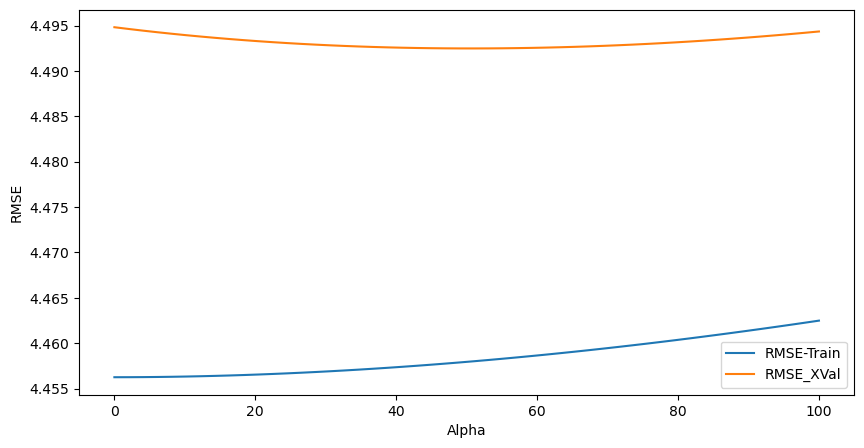

In [60]:
fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.plot(alpha, t_rmse, label='RMSE-Train')
ax.plot(alpha, cv_rmse, label='RMSE_XVal')
pl.legend( ('RMSE-Train', 'RMSE_XVal') )
pl.ylabel('RMSE')
pl.xlabel('Alpha')
pl.show()

In [61]:
best_result = min(results, key=lambda x: x['rmse_cv'])
best_alpha = best_result['alpha']
best_rmse_cv = best_result['rmse_cv']
best_alpha

51.025306122448974

In [62]:
# Create linear regression object with the best alpha
ridge = Ridge(alpha=best_alpha)

# Train the model using the training set
ridge.fit(X_train, y_train)

p_train = ridge.predict(X_train) # p_train is the array of predicted training values
rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

# Compute RMSE on the set-aside test data

p_test = ridge.predict(X_test) # predictions on the test instances
rmse_test = np.sqrt(mean_squared_error(p_test, y_test))

method_name = 'Ridge Regression'
print("\n")
print('Method: %s' %method_name)
print('RMSE on training: %.4f' %rmse_train)
print('RMSE on test data: %.4f' %rmse_test)



Method: Ridge Regression
RMSE on training: 4.4580
RMSE on test data: 4.0014


# Lasso Regression

Lasso Regression


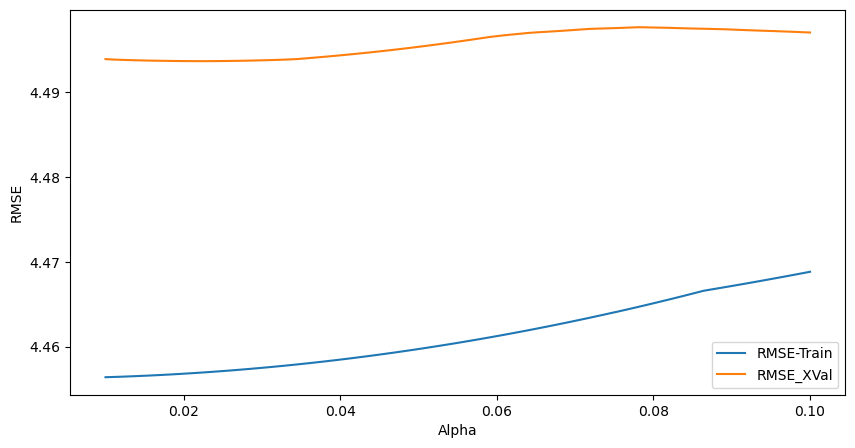

In [64]:
print('Lasso Regression')
# print('alpha\t RMSE_train\t RMSE_10cv\t Gap\n')
alpha = np.linspace(0.01,0.1,100) # create an array of 50 evenly spaced numbers between 0.01 and 5.0
t_rmse = np.array([])
cv_rmse = np.array([])
results=[]
for a in alpha:
    lasso = Lasso(alpha=a)
    
    # computing the RMSE on training data
    lasso.fit(X_train, y_train)
    p_train = lasso.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

    # Compute RMSE using 10-fold x-validation
    rmse_10cv = cross_validate(lasso, X_train, y_train, 10)
    
    gap = rmse_10cv - rmse_train
    
    t_rmse = np.append(t_rmse, [rmse_train])
    cv_rmse = np.append(cv_rmse, [rmse_10cv])

    results.append({
        'alpha': a,
        'rmse_train': rmse_train,
        'rmse_cv': rmse_10cv,
        'gap': gap
    })

    # print('{:.3f}\t {:.4f}\t\t {:.4f}\t\t {:.4f}'.format(a,rmse_train,rmse_10cv,gap))
    
fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.plot(alpha, t_rmse, label='RMSE-Train')
ax.plot(alpha, cv_rmse, label='RMSE_XVal')
pl.legend( ('RMSE-Train', 'RMSE_XVal') )
pl.ylabel('RMSE')
pl.xlabel('Alpha')
pl.show()

In [65]:
best_result = min(results, key=lambda x: x['rmse_cv'])
best_alpha = best_result['alpha']
best_rmse_cv = best_result['rmse_cv']
best_alpha

0.022727272727272728

In [66]:
# Let's pick 0.3 for lasso regularization coefficient
lasso = Lasso(alpha=best_alpha)

# Train the model using the training set
lasso.fit(X_train, y_train)

p_train = lasso.predict(X_train) # p_train is the array of predicted training values
rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

# Compute RMSE on the set-aside test data

p_test = lasso.predict(X_test) # predictions on the test instances
rmse_test = np.sqrt(mean_squared_error(p_test, y_test))

method_name = 'Lasso Regression'
print("\n")
print('Method: %s' %method_name)
print('RMSE on training: %.4f' %rmse_train)
print('RMSE on test data: %.4f' %rmse_test)



Method: Lasso Regression
RMSE on training: 4.4570
RMSE on test data: 3.9842


# Elastic Net Regression

In [68]:
from sklearn.linear_model import ElasticNet

Elastic Net Regression
alpha	 RMSE_train	 RMSE_10cv	 Gap



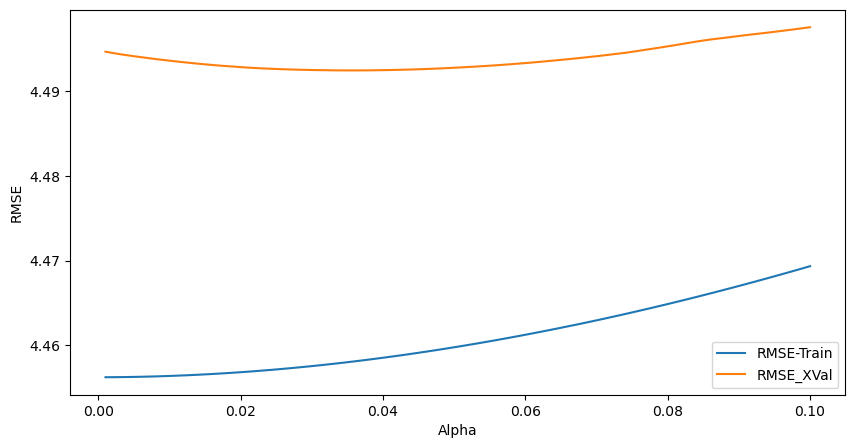

In [69]:
print('Elastic Net Regression')
print('alpha\t RMSE_train\t RMSE_10cv\t Gap\n')
alpha = np.linspace(.001,0.1,100) # create an array of 50 evenly spaced numbers between 0.01 and 5.0
t_rmse = np.array([])
cv_rmse = np.array([])
results=[]
for a in alpha:
    elastic = ElasticNet(alpha=a, l1_ratio=0.5)
    
    # computing the RMSE on training data
    elastic.fit(X_train, y_train)
    p_train = elastic.predict(X_train)
    rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

    # Compute RMSE using 10-fold x-validation
    rmse_10cv = cross_validate(elastic, X_train, y_train, 10)
    
    gap = rmse_10cv - rmse_train
    
    t_rmse = np.append(t_rmse, [rmse_train])
    cv_rmse = np.append(cv_rmse, [rmse_10cv])
    results.append({
        'alpha': a,
        'rmse_train': rmse_train,
        'rmse_cv': rmse_10cv,
        'gap': gap
    })
  
    #print('{:.3f}\t {:.4f}\t\t {:.4f}\t\t {:.4f}'.format(a,rmse_train,rmse_10cv,gap))
    
fig = pl.figure(figsize=(10,5))
ax = fig.add_subplot(111)
ax.plot(alpha, t_rmse, label='RMSE-Train')
ax.plot(alpha, cv_rmse, label='RMSE_XVal')
pl.legend( ('RMSE-Train', 'RMSE_XVal') )
pl.ylabel('RMSE')
pl.xlabel('Alpha')
pl.show()

In [70]:
best_result = min(results, key=lambda x: x['rmse_cv'])
best_alpha = best_result['alpha']
best_rmse_cv = best_result['rmse_cv']
best_alpha

0.036000000000000004

In [71]:
# Let's pick 0.3 for lasso regularization coefficient
elastic = ElasticNet(alpha=best_alpha)

# Train the model using the training set
elastic.fit(X_train, y_train)

p_train = elastic.predict(X_train) # p_train is the array of predicted training values
rmse_train = np.sqrt(mean_squared_error(p_train, y_train))

# Compute RMSE on the set-aside test data

p_test = elastic.predict(X_test) # predictions on the test instances
rmse_test = np.sqrt(mean_squared_error(p_test, y_test))

method_name = 'Elastic Net Regression'
print("\n")
print('Method: %s' %method_name)
print('RMSE on training: %.4f' %rmse_train)
print('RMSE on test data: %.4f' %rmse_test)



Method: Elastic Net Regression
RMSE on training: 4.4581
RMSE on test data: 3.9984


# RANDOM FOREST?

In [73]:
# Bin life expectancy into categories for classification
df_tree = df.copy()
bins = [0, 60, 75, 90]  # Define your bins
labels = ['Low', 'Medium', 'High']
df_tree['Life_expectancy_category'] = pd.cut(df_tree['Life expectancy'], bins=bins, labels=labels)

# Use this categorical target for classification
target_class = df_tree['Life_expectancy_category']
X_class = np.array(df_tree.drop(['Life expectancy', 'Life_expectancy_category', 'Country', 'Status', 'Adult Mortality'], axis=1))
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(X_class, target_class, test_size=0.2, random_state=33)

In [74]:
# Now you can use classification models
dt = tree.DecisionTreeClassifier(criterion='entropy', random_state=33)
dt = dt.fit(X_train_c, y_train_c)
y_pred_class = dt.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_class)
print(f"Decision Tree Classification Accuracy: {accuracy:.3f}")

Decision Tree Classification Accuracy: 0.902


In [75]:
from sklearn import metrics
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
rf = RandomForestClassifier(n_estimators=10, random_state=33)
rf = rf.fit(X_train_c, y_train_c)
def measure_performance(X, y, clf, show_accuracy=True, show_classification_report=True, show_confussion_matrix=True):
    y_pred = clf.predict(X)   
    if show_accuracy:
         print("Accuracy:{0:.3f}".format(metrics.accuracy_score(y, y_pred)),"\n")
    if show_classification_report:
        print("Classification report")
        print(metrics.classification_report(y, y_pred),"\n")
      
    if show_confussion_matrix:
        print("Confusion matrix")
        print(metrics.confusion_matrix(y, y_pred),"\n")

print("Random Forest Performance:")
measure_performance(X_test_c, y_test_c, rf, show_confussion_matrix=True, show_classification_report=True)

Random Forest Performance:
Accuracy:0.913 

Classification report
              precision    recall  f1-score   support

        High       0.94      0.86      0.90       137
         Low       0.91      0.96      0.93       102
      Medium       0.90      0.92      0.91       232

    accuracy                           0.91       471
   macro avg       0.92      0.91      0.91       471
weighted avg       0.91      0.91      0.91       471
 

Confusion matrix
[[118   0  19]
 [  0  98   4]
 [  8  10 214]] 



In [76]:
# RandomForestClassifier
param_grid = {
    'n_estimators': [50, 75, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'criterion' :['gini', 'entropy']
}

rf_class = RandomForestClassifier(random_state=33)
grid_search = GridSearchCV(rf_class, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train_c, y_train_c)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=33),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 75, 100]},
             scoring='accuracy')

In [77]:
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_:.3f}")

Best parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best score: 0.934


In [78]:
# New model with the best parameters
rf_class = RandomForestClassifier(**grid_search.best_params_, random_state=33)
rf_class.fit(X_train_c, y_train_c)
y_pred_class = rf_class.predict(X_test_c)

accuracy = accuracy_score(y_test_c, y_pred_class)
print(f"Random Forest Classification Accuracy: {accuracy:.3f}")

Random Forest Classification Accuracy: 0.932


In [79]:
measure_performance(X_test_c, y_test_c, rf_class, show_confussion_matrix=False, show_classification_report=True)

Accuracy:0.932 

Classification report
              precision    recall  f1-score   support

        High       0.97      0.85      0.91       137
         Low       0.97      0.95      0.96       102
      Medium       0.90      0.97      0.93       232

    accuracy                           0.93       471
   macro avg       0.95      0.92      0.93       471
weighted avg       0.94      0.93      0.93       471
 



In [80]:
rf_class.feature_importances_

array([0.051325  , 0.02003532, 0.0198781 , 0.09215587, 0.07331279,
       0.03464278, 0.04354525, 0.03075991, 0.15178566, 0.05615478,
       0.09667807, 0.21939507, 0.1103314 ])

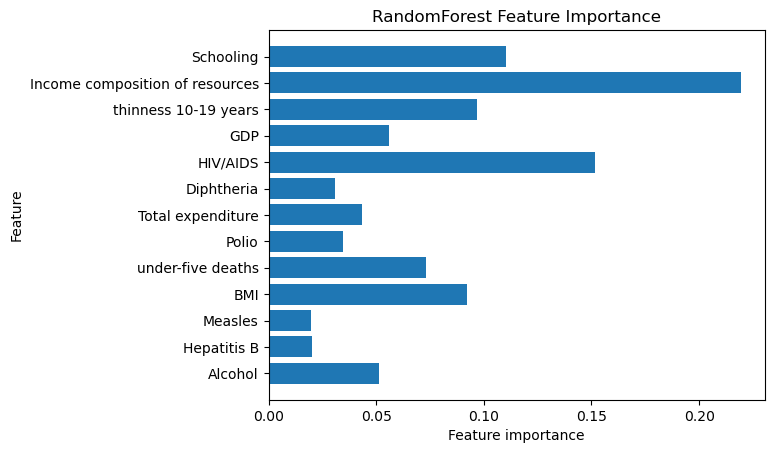

In [81]:
def plot_feature_importances(model, n_features, feature_names):
    plt.barh(range(n_features), model.feature_importances_, align='center')
    plt.yticks(np.arange(n_features), feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.title('RandomForest Feature Importance')
    plt.ylim(-1, n_features)
    
n_features = len(rf_class.feature_importances_)
features = (df_tree.drop(['Life expectancy', 'Life_expectancy_category', 'Country', 'Status', 'Adult Mortality'], axis=1)).columns
plot_feature_importances(rf_class, len(features), features)
pl.show()

# K-Means?

In [191]:
# Only numerical features are used
df_k1 = df.copy()
df_k1 = df_k1.drop(['Country', 'Status'], axis=1)
df_k = scaler.fit_transform(df_k1)

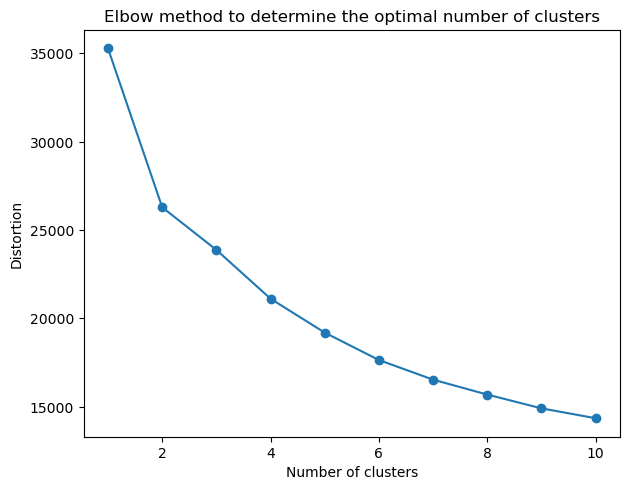

In [84]:
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, 
                init='k-means++', 
                n_init=10, 
                max_iter=300, 
                random_state=0)
    km.fit(df_k)
    wcss.append(km.inertia_)
pl.plot(range(1, 11), wcss, marker='o')
pl.xlabel('Number of clusters')
pl.ylabel('Distortion')
pl.tight_layout()
pl.title('Elbow method to determine the optimal number of clusters')
pl.show()

In [193]:
# Only numerical features are used
df_k1 = df.copy()
df_k1 = df_k1.drop(['Country', 'Status'], axis=1)
df_k = scaler.fit_transform(df_k1)

In [195]:
# The elbow method does not return a decisive conclusion about cluster size.
# There is no plateau after 2 clusters, so 2 clusters 
kmeans = KMeans(n_clusters=2, max_iter=200, init='k-means++', n_init=5, verbose=1, random_state=33)
kmeans.fit(df_k)

Initialization complete
Iteration 0, inertia 55660.86366957937.
Iteration 1, inertia 32290.839973488277.
Iteration 2, inertia 32141.813508247225.
Iteration 3, inertia 32102.499783817082.
Iteration 4, inertia 32093.366165539897.
Iteration 5, inertia 32087.81265418979.
Iteration 6, inertia 32085.056108586232.
Iteration 7, inertia 32083.17663027749.
Iteration 8, inertia 32080.791731492132.
Iteration 9, inertia 32079.90191657839.
Converged at iteration 9: strict convergence.
Initialization complete
Iteration 0, inertia 48621.059184014106.
Iteration 1, inertia 26344.611077794943.
Iteration 2, inertia 26296.262927084972.
Iteration 3, inertia 26291.877795143017.
Iteration 4, inertia 26290.92340031201.
Converged at iteration 4: strict convergence.
Initialization complete
Iteration 0, inertia 40247.58892217486.
Iteration 1, inertia 31814.764897455494.
Iteration 2, inertia 28888.051266647028.
Iteration 3, inertia 27110.110045588277.
Iteration 4, inertia 26457.347546769895.
Iteration 5, inertia 2

KMeans(max_iter=200, n_clusters=2, n_init=5, random_state=33, verbose=1)

In [203]:
clusters = kmeans.predict(df_k)
print(clusters)

[1 1 1 ... 1 1 1]


In [205]:
pd.options.display.float_format='{:,.2f}'.format
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=df_k1.columns)
centroids

,Life expectancy,Adult Mortality,Alcohol,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,thinness 10-19 years,Income composition of resources,Schooling
0,0.62,-0.42,0.32,0.30,-0.15,0.49,-0.22,0.42,0.14,0.42,-0.31,0.27,-0.42,0.58,0.58
1,-0.96,0.66,-0.49,-0.47,0.24,-0.77,0.34,-0.65,-0.21,-0.66,0.49,-0.42,0.65,-0.90,-0.90


Based on the centroids, it can be speculated that cluster 0 represents 'Developed'countries, while cluster 1 represents 'Developing' countries. Cluster 0 has generally higher values for favorable features, such as life expectancy, GDP, and schooling. Cluster 1 has generally higher values for negative features, such as adult mortality, under-five deaths, and Measles.

In [207]:
def cluster_sizes(clusters):
    #clusters is an array of cluster labels for each instance in the data
    
    size = {}
    cluster_labels = np.unique(clusters)
    n_clusters = cluster_labels.shape[0]

    for c in cluster_labels:
        size[c] = len(df_k[clusters == c])
    return size
size = cluster_sizes(clusters)
for c in size.keys():
    print("Size of Cluster", c, "= ", size[c])

Size of Cluster 0 =  1432
Size of Cluster 1 =  920


In [209]:
print(df['Status'].value_counts())

Status
Developing    2016
Developed      336
Name: count, dtype: int64


In [211]:
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters

# Check how Status maps to clusters
cluster_status = pd.crosstab(df_with_clusters['Cluster'], df_with_clusters['Status'])
print(cluster_status)

# Calculate accuracy if we assume Cluster 0 = Developed
accuracy = (cluster_status.loc[0, 'Developed'] + cluster_status.loc[1, 'Developing']) / len(df_with_clusters)
print(f"Accuracy: {accuracy:.2%}")

Status   Developed  Developing
Cluster                       
0              336        1096
1                0         920
Accuracy: 53.40%


In [213]:
# Check the mapping between clusters and status
status_by_cluster = df_with_clusters.groupby('Cluster')['Status'].value_counts()
print("Status distribution by cluster:")
print(status_by_cluster)
print()

Status distribution by cluster:
Cluster  Status    
0        Developing    1096
         Developed      336
1        Developing     920
Name: count, dtype: int64



In [215]:
# Determine which cluster corresponds to which status
# Based on the centroids, Cluster 0 should be Developed, Cluster 1 should be Developing
cluster_0_status = df_with_clusters[df_with_clusters['Cluster'] == 0]['Status'].mode()[0]
cluster_1_status = df_with_clusters[df_with_clusters['Cluster'] == 1]['Status'].mode()[0]

print(f"Cluster 0 predominantly contains: {cluster_0_status} countries")
print(f"Cluster 1 predominantly contains: {cluster_1_status} countries")
print()

Cluster 0 predominantly contains: Developing countries
Cluster 1 predominantly contains: Developing countries



In [217]:
# Calculate accuracy
# Method 1: Simple accuracy based on majority class in each cluster
def calculate_clustering_accuracy(df_with_clusters):
    correct_predictions = 0
    total_instances = len(df_with_clusters)
    
    for cluster in [0, 1]:
        cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
        majority_status = cluster_data['Status'].mode()[0]
        
        # Count how many in this cluster have the correct status
        correct_in_cluster = (cluster_data['Status'] == majority_status).sum()
        correct_predictions += correct_in_cluster
        
        print(f"Cluster {cluster}: {correct_in_cluster}/{len(cluster_data)} correct "
              f"({correct_in_cluster/len(cluster_data)*100:.1f}%)")
    
    accuracy = correct_predictions / total_instances
    return accuracy

# Calculate accuracy
accuracy = calculate_clustering_accuracy(df_with_clusters)
print(f"\nOverall clustering accuracy: {accuracy:.3f} ({accuracy*100:.1f}%)")

Cluster 0: 1096/1432 correct (76.5%)
Cluster 1: 920/920 correct (100.0%)

Overall clustering accuracy: 0.857 (85.7%)


Status distribution by cluster:
Cluster  Status    
0        Developing   0.77
         Developed    0.23
1        Developing   1.00
Name: proportion, dtype: float64


Count of each Status by cluster:
Status   Developed  Developing
Cluster                       
0              336        1096
1                0         920


Percentage distribution:
Status   Developed  Developing
Cluster                       
0            23.46       76.54
1             0.00      100.00


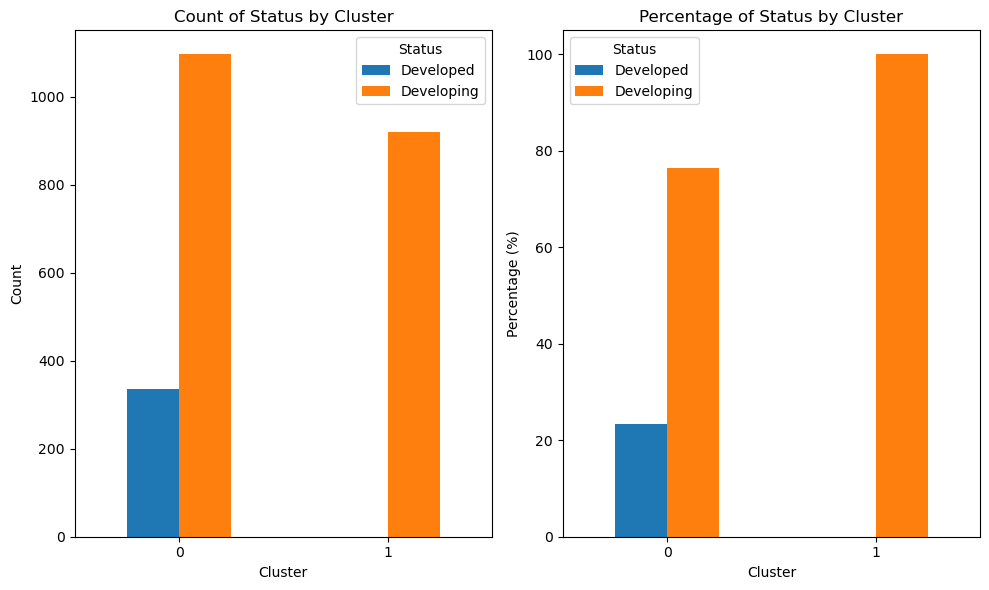



Cluster interpretation:
Cluster 0:
  Developed countries: 23.5%
  Developing countries: 76.5%
  Total countries: 1432
Cluster 1:
  Developed countries: 0.0%
  Developing countries: 100.0%
  Total countries: 920


In [219]:
# Add cluster labels back to the original dataframe
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters

# Check Status distribution in each cluster
print("Status distribution by cluster:")
print(df_with_clusters.groupby('Cluster')['Status'].value_counts(normalize=True))

print("\n\nCount of each Status by cluster:")
status_counts = df_with_clusters.groupby(['Cluster', 'Status']).size().unstack(fill_value=0)
print(status_counts)

# Calculate percentages
status_percentages = df_with_clusters.groupby('Cluster')['Status'].value_counts(normalize=True).unstack(fill_value=0) * 100
print("\n\nPercentage distribution:")
print(status_percentages.round(2))

# Visualize the results
plt.figure(figsize=(10, 6))

# Count plot
plt.subplot(1, 2, 1)
status_counts.plot(kind='bar', ax=plt.gca())
plt.title('Count of Status by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.legend(title='Status')
plt.xticks(rotation=0)

# Percentage plot
plt.subplot(1, 2, 2)
status_percentages.plot(kind='bar', ax=plt.gca())
plt.title('Percentage of Status by Cluster')
plt.xlabel('Cluster')
plt.ylabel('Percentage (%)')
plt.legend(title='Status')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Check if clusters match development status
print("\n\nCluster interpretation:")
for cluster in sorted(df_with_clusters['Cluster'].unique()):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    developed_pct = (cluster_data['Status'] == 'Developed').mean() * 100
    developing_pct = (cluster_data['Status'] == 'Developing').mean() * 100
    
    print(f"Cluster {cluster}:")
    print(f"  Developed countries: {developed_pct:.1f}%")
    print(f"  Developing countries: {developing_pct:.1f}%")
    print(f"  Total countries: {len(cluster_data)}")

In [221]:
# Detailed analysis by country type
print("\nDetailed Analysis:")
for status in ['Developing', 'Developed']:
    status_data = df_with_clusters[df_with_clusters['Status'] == status]
    correct_cluster = 0 if status == 'Developed' else 1  # Based on our assumption
    
    correctly_clustered = (status_data['Cluster'] == correct_cluster).sum()
    total_status = len(status_data)
    status_accuracy = correctly_clustered / total_status
    
    print(f"{status} countries: {correctly_clustered}/{total_status} correctly clustered "
          f"({status_accuracy*100:.1f}%)")


Detailed Analysis:
Developing countries: 920/2016 correctly clustered (45.6%)
Developed countries: 336/336 correctly clustered (100.0%)


Clustering was effective at creating a separate cluster for 'Developing' countries. However, it struggled with separating 'Developed' countries. In reality, these statuses are not clearly defined and there might be several 'Developing' countries that are close to transitioning to 'Developed' status, thus getting clustered together. Cluster 1 likely represents countries that are struggling more severely.